In [1]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da

In [2]:
# reading in ERA5 to compare

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# Define the range of years and months
years = [str(year) for year in range(1979, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component
u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

w_files = get_files('vertical_velocity', 'vertical_velocity')

q_files = get_files('specific_humidity', 'specific_humidity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once

era5 = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

era5sgp = era5.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

era5sgp['time'] = era5sgp['time'] - pd.Timedelta(hours=6)

In [3]:
#subsetting for 2011

era2011 = era5sgp.where(era5sgp['time'].dt.year == 2011, drop=True)

night = era2011.sel(time=era2011['time'].dt.hour.isin([0, 6]))

day = era2011.sel(time=era2011['time'].dt.hour.isin([12, 18]))

full = era2011.sel(time=era2011['time'].dt.hour.isin([0, 6, 12, 18]))

night = night.resample(time='ME').mean()

day = day.resample(time='ME').mean()

full = full.resample(time='ME').mean()

In [4]:
# subsetting for climatology

clim = era5sgp.sel(time=slice('1979-01-01', '2018-12-31'))

cnight = clim.sel(time=clim['time'].dt.hour.isin([0, 6]))

cday = clim.sel(time=clim['time'].dt.hour.isin([12, 18]))

cfull = clim.sel(time=clim['time'].dt.hour.isin([0, 6, 12, 18]))

cnight = cnight.groupby('time.month').mean('time')

cday = cday.groupby('time.month').mean('time')

cfull = cfull.groupby('time.month').mean('time')

In [7]:
all_times = {
    
#     'clim full': cfull,
    
    '2011 night': night,
    
    '2011 day': day
        
#     'clim night': cnight,
    
#     'clim day': cday 
    
}

In [9]:
def calculate_horizontal_advection_annie_fixed(u, v, q, lat, lon):
    """
    Calculate horizontal moisture advection on a spherical grid.

    u, v, q: arrays of shape (levels, lat, lon)
    lat, lon: 1D arrays in degrees
    Returns: zonal and meridional advection averaged over the domain per level
    """
    R = 6371000  # Earth radius (m)
    
    rho_water = 1000  # kg/m^3
    
    seconds_to_day = 86400  # s/day

    # grid spacing in radians
    
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)
    
    delta_y = lat_rad[1] - lat_rad[0]
    
    delta_x = lon_rad[1] - lon_rad[0]

    # 2D latitude/longitude grids in radians
    
    lon2d, lat2d = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat2d)

    # initialize derivatives
    
    dqdx = np.zeros_like(q)
    
    dqdy = np.zeros_like(q)

    # compute derivatives for each vertical level
    for k in range(u.shape[0]):
        
        # central differences interior
        
        dqdx[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * delta_x)
        
        dqdy[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * delta_y)

        # boundaries (forward/backward differences)
        
        dqdx[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / delta_x
        
        dqdx[k, :, -1] = (q[k, :, -1] - q[k, :, -2]) / delta_x
        
        dqdy[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / delta_y
        
        dqdy[k, -1, :] = (q[k, -1, :] - q[k, -2, :]) / delta_y

        # convert to physical derivatives
        
        dqdx[k] = dqdx[k] / (R * cos_lat)
        
        dqdy[k] = dqdy[k] / R

    # horizontal advection
    
    zonal_adv = -(u * dqdx)
    
    merid_adv = -(v * dqdy)

    # compute grid cell areas
    
    dx = R * cos_lat * delta_x
    
    dy = R * delta_y
    
    cell_area = dx * dy
        
    A = np.sum(cell_area)

    # area-weighted average per level
    
    zonal_avg = np.sum(zonal_adv * cell_area, axis=(1, 2)) / A * seconds_to_day * rho_water
    
    merid_avg = np.sum(merid_adv * cell_area, axis=(1, 2)) / A * seconds_to_day * rho_water

    return zonal_avg, merid_avg


In [10]:
u = full['u'].load().data[:, :, ::-1, :]
print("u loaded")

v = full['v'].load().data[:, :, ::-1, :]
print("v loaded")

q = full['q'].load().data[:, :, ::-1, :] 
print("q loaded")

w = full['w'].load().data[:, :, ::-1, :] 
print("w loaded")

pressure = full['level'].data * 100 

latitude = full['latitude'].data[::-1]

longitude = full['longitude'].data

u loaded
v loaded
q loaded
w loaded


In [11]:
# to append

zonal_advection_profile = []

meridional_advection_profile = []

# Looping over every month
months = u.shape[0]

for i in range(months):

    # horizontal advection
    zonal_adv, merid_adv = calculate_horizontal_advection_annie_fixed(u[i], v[i], q[i], latitude, longitude)
    
    # append horizontal advection
    
    zonal_advection_profile.append(zonal_adv)
    
    meridional_advection_profile.append(merid_adv)
    
zonal_advection_profile = np.array(zonal_advection_profile)

meridional_advection_profile = np.array(meridional_advection_profile)

## plotting advection Hovmoller diagrams below

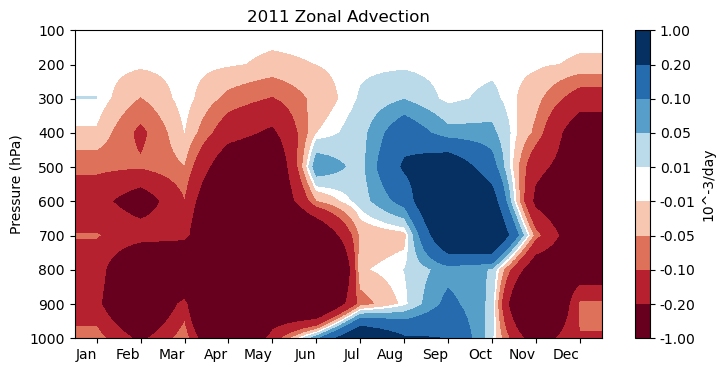

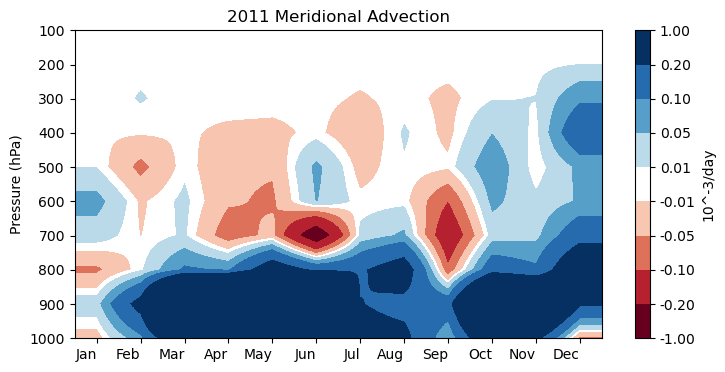

In [13]:
profs_to_plot = [zonal_advection_profile, meridional_advection_profile]

titles = ['Zonal', 'Meridional', 'Vertical']

pressure_levels = full['level'].data

levels = np.array([-1, -0.2, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.2, 1])

colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', 'white', 'white', '#92c5de', '#4393c3', '#2166ac', '#053061']

cmap = mcolors.LinearSegmentedColormap.from_list("custom_coolwarm", colors, N=len(levels) - 1)

norm = mcolors.BoundaryNorm(levels, ncolors=len(levels) - 1, clip=True)

# Subset pressure levels and data to go up to 100 hPa
pressure_subset = pressure_levels[(pressure_levels >= 100) & (pressure_levels % 100 == 0)]

pressure_indices = np.isin(pressure_levels, pressure_subset).nonzero()[0]  # Indices for data subsetting

for i, arr in enumerate(profs_to_plot):
    
    plt.figure(figsize=(8.5, 4))
    
    # Subset data to match the pressure range up to 100 hPa
    hovmoller_data = np.array(arr)[:, pressure_indices]

    # Plot data without forcing extent to allow automatic scaling
    plt.imshow(hovmoller_data.T, aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')
    
    # Set x-axis labels
    plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
               ha='right')

    plt.ylim(0, len(pressure_subset) - 1)  # Reverse to show top level first
    
    plt.yticks(np.arange(len(pressure_subset)), pressure_subset)

    plt.ylabel('Pressure (hPa)')

    # Color bar with custom tick labels
    cbar = plt.colorbar(label='10^-3/day', ticks=levels)
    cbar.ax.set_yticklabels(['<-0.2', '-0.2', '-0.1', '-0.05', '-0.01', '0.01', '0.05', '0.1', '0.2', '>0.2'])

    cbar.ax.set_yticklabels([f"{level:.2f}" for level in levels])

    # Set title and show plot
    plt.title('2011 {} Advection'.format(titles[i]))
    
    plt.gca().invert_yaxis()
    
    plt.show()

In [21]:
def vertically_integrated_advection(u, v, q, levels, lat, lon):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    mm_to_m = 1000

    # Get the moisture budget profiles
    zonal_advection_area_weighted, meridional_advection_area_weighted = calculate_horizontal_advection_annie_fixed(u, v, q, lat, lon)
                    
    # Calculate dp, with the sign depending on your dataset's vertical structure
    dp = np.diff(levels)
    
    # Create a dictionary to store the input profiles and the integrated results
    profiles = {
        "zonal_advection_integrated": zonal_advection_area_weighted,
        "meridional_advection_integrated": meridional_advection_area_weighted}
    
    integrated_results = {}  # Dictionary to store integrated results
    
    for name, profile in profiles.items():
                
        integrated_results[name] = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water))

    return integrated_results

In [22]:
integrated_results = {}  # Main dictionary to store results for all datasets

for df_name, df in all_times.items():
    
    print(df_name)
    
    identifier = df_name
    
    u = df['u'].load().data[:, :, ::-1, :] 
    print("u loaded")
    
    v = df['v'].load().data[:, :, ::-1, :]
    print("v loaded")
        
    q = df['q'].load().data[:, :, ::-1, :] 
    print("q loaded")
    
    levels = df['level'].data * 100 
    
    lat = df['latitude'].data[::-1]
    
    lon = df['longitude'].data
    
    months = u.shape[0]
    
    integrated_results[df_name] = {
        "zonal adv": [],
        "merid adv": []}
    
    # Loop over every month 
    for i in range(months):

        advection_results = vertically_integrated_advection(u[i], v[i], q[i], levels, lat, lon)
        
        # Append the results to the corresponding lists
        integrated_results[df_name]["zonal adv"].append(advection_results["zonal_advection_integrated"])
        
        integrated_results[df_name]["merid adv"].append(advection_results["meridional_advection_integrated"])
        

2011 night
u loaded
v loaded
q loaded
2011 day
u loaded
v loaded
q loaded


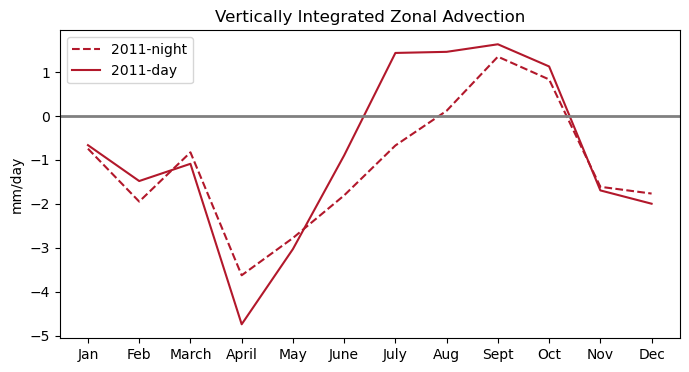

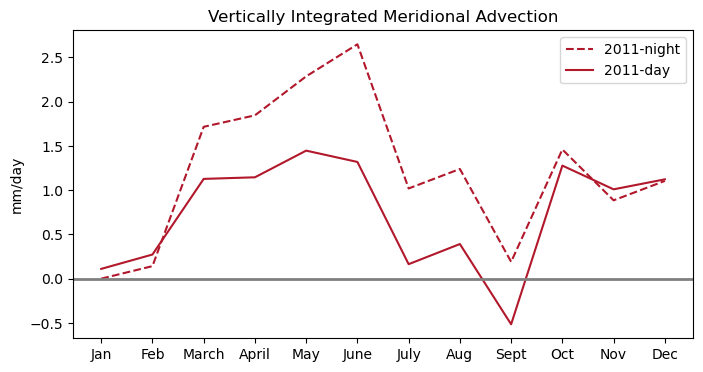

In [24]:
# zonal

fig, ax = plt.subplots(figsize=(8, 4))

months=["Jan", "Feb", "March", "April", "May", "June", "July", "Aug", "Sept", "Oct", "Nov", "Dec"]

plt.plot(months, integrated_results['2011 night']['zonal adv'], color='#b2182b', linestyle='--', label='2011-night')

plt.plot(months, integrated_results['2011 day']['zonal adv'], color='#b2182b', label='2011-day')

# plt.plot(months, integrated_results['clim night']['zonal adv'], color='blue', linestyle='--', label='clim-night')

# plt.plot(months, integrated_results['clim day']['zonal adv'], color='blue', label='clim-day')

plt.axhline(0, color='grey', linewidth=2)

plt.ylabel("mm/day")

plt.title("Vertically Integrated Zonal Advection")

# plt.ylim(-5,2)

plt.legend()

plt.show()


# meridional 

fig, ax = plt.subplots(figsize=(8, 4))

months=["Jan", "Feb", "March", "April", "May", "June", "July", "Aug", "Sept", "Oct", "Nov", "Dec"]

plt.plot(months, integrated_results['2011 night']['merid adv'], color='#b2182b', linestyle='--', label='2011-night')

plt.plot(months, integrated_results['2011 day']['merid adv'], color='#b2182b', label='2011-day')

# plt.plot(months, integrated_results['clim night']['merid adv'], color='blue', linestyle='--', label='clim-night')

# plt.plot(months, integrated_results['clim day']['merid adv'], color='blue', label='clim-day')

plt.axhline(0, color='grey', linewidth=2)

plt.title("Vertically Integrated Meridional Advection")

plt.ylabel("mm/day")

# plt.ylim(-5,2)

plt.legend()

plt.show()